<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

I0000 00:00:1787009180.448827   21090 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787009180.497658   21090 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787009181.315081   21090 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Datos

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [4]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [5]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [6]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [7]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [8]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

67

In [9]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [10]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [11]:
tokenized_text[:1000]

[24,
 33,
 9,
 24,
 33,
 10,
 24,
 39,
 16,
 1,
 24,
 4,
 27,
 25,
 53,
 65,
 24,
 10,
 39,
 24,
 41,
 39,
 26,
 39,
 24,
 9,
 31,
 64,
 33,
 66,
 1,
 24,
 25,
 24,
 42,
 33,
 24,
 26,
 39,
 38,
 62,
 10,
 10,
 33,
 13,
 66,
 1,
 15,
 65,
 24,
 54,
 46,
 66,
 10,
 62,
 9,
 23,
 2,
 1,
 9,
 24,
 23,
 39,
 66,
 42,
 33,
 9,
 26,
 24,
 6,
 34,
 42,
 1,
 9,
 42,
 33,
 24,
 64,
 46,
 66,
 62,
 22,
 24,
 26,
 47,
 33,
 66,
 62,
 42,
 39,
 9,
 24,
 33,
 9,
 24,
 4,
 27,
 4,
 28,
 34,
 24,
 33,
 26,
 2,
 39,
 54,
 39,
 24,
 47,
 39,
 54,
 62,
 2,
 39,
 42,
 39,
 24,
 59,
 1,
 66,
 24,
 59,
 47,
 62,
 10,
 33,
 39,
 26,
 24,
 43,
 1,
 23,
 23,
 65,
 24,
 35,
 46,
 62,
 33,
 9,
 24,
 39,
 6,
 24,
 59,
 33,
 26,
 39,
 66,
 24,
 42,
 33,
 24,
 35,
 46,
 33,
 24,
 59,
 39,
 66,
 33,
 41,
 18,
 39,
 24,
 47,
 39,
 54,
 33,
 66,
 24,
 2,
 1,
 64,
 39,
 42,
 1,
 24,
 33,
 10,
 24,
 59,
 39,
 66,
 2,
 62,
 42,
 1,
 24,
 42,
 33,
 24,
 9,
 1,
 24,
 47,
 39,
 41,
 33,
 66,
 24,
 9,
 39,
 42,
 39,
 24,
 3

### Organizando y estructurando el dataset

In [12]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [13]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [14]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [15]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [16]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [17]:
X.shape

(355829, 100)

In [18]:
X[0,:10]

array([24, 33,  9, 24, 33, 10, 24, 39, 16,  1])

In [19]:
y[0,:10]

array([33,  9, 24, 33, 10, 24, 39, 16,  1, 24])

In [20]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [21]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [22]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/home/gerardo/miniforge3/envs/nlp-uba-tf/lib/python3.11/site-packages/keras/src/layers/core/wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1787009253.403931   21090 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,067 (261.98 KB)

 Trainable params: 67,067 (261.98 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [23]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [24]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20


I0000 00:00:1786982404.841333   70396 service.cc:153] XLA service 0x56443d090890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786982404.841357   70396 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2060, Compute Capability 7.5 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786982404.971003   70396 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1786982404.991956   70396 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1786982405.037119   70396 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786982405.094361   70396 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_5253_grad_5476_const_0__.21.clone.clone.clone.clone.clone.clone
I0000 00:00:1786982405.094480   7

   9/1390 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 3.4637 

I0000 00:00:1786982406.866758   70396 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1389/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2208

W0000 00:00:1786982427.658404   70394 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1786982427.743772   70394 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_5253_grad_5476_const_0__.21.clone.clone.clone.clone.clone.clone
I0000 00:00:1786982427.743851   70394 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5784__.22


1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.2206
 mean perplexity: 6.380901063759315 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - loss: 2.2206
Epoch 2/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.9162
 mean perplexity: 5.413179370352459 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 1.9162
Epoch 3/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.8277
 mean perplexity: 5.147494080102988 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - loss: 1.8277
Epoch 4/20
1389/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7862
 mean perplexity: 4.942914908307458 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - loss: 1.7862
Epoch 5/20
1387/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.7615
 mean perplexity: 4.866365210053885 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - loss: 1.7615
Epoch 6/20
1387/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.7448
 mean perplexity

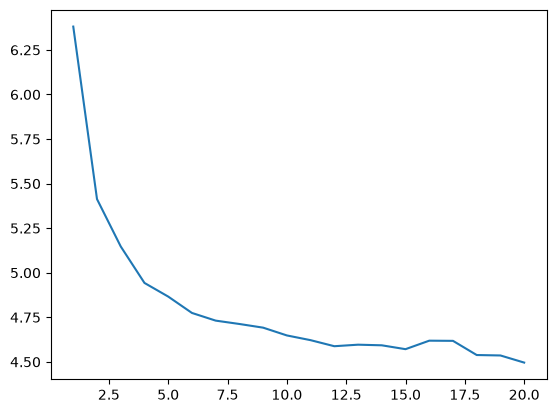

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [26]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [27]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [28]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Created dataset file at: .gradio/flagged/dataset1.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Keyboard interruption in main thread... closing server.


### Generación de secuencias

In [30]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [31]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'habia una vez en el compañero a la compañía'

###  Beam search y muestreo aleatorio

In [32]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [33]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [34]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [35]:
salidas[0]

array([41, 29,  4, 27, 29, 36,  8, 16, 29, 36, 40, 32, 13, 36, 32, 16, 36,
       28,  8, 29, 16, 35, 63, 36, 32, 23, 30, 29,  4, 29, 36, 32, 16])

In [36]:
# veamos las salidas
decode(salidas[0])

'habia una vez en cuando estaba en'

# Resolución — Modelo de lenguaje por caracteres sobre el corpus FOMC

**Corpus elegido: actas y comunicados del FOMC (2000-2026)**, el mismo que utilicé en el 
Desafío 2. Las razones:

1. **Continuidad metodológica.** Ya conozco el corpus en profundidad: su tamaño (1,8 millones 
   de palabras), su composición (95% actas), sus problemas de codificación y su carácter 
   formulaico. Ese conocimiento previo me permite anticipar decisiones de preprocesamiento en 
   lugar de descubrirlas sobre la marcha.

2. **Interés de investigación.** Sigo trabajando sobre discursos de política económica, en 
   línea con mi tesis de doctorado.



In [37]:
import pandas as pd

url = "https://raw.githubusercontent.com/vtasca/fed-statement-scraping/master/communications.csv"
df = pd.read_csv(url)

# Unimos todo el texto en un solo string: para un modelo de lenguaje por caracteres,
# el corpus completo es un único "documento" continuo
corpus = " ".join(df['Text'].tolist())

print(f"Documentos: {len(df)}")
print(f"Caracteres totales del corpus: {len(corpus):,}")
print(f"\nPrimeros 300 caracteres:")
print(corpus[:300])

Documentos: 467
Caracteres totales del corpus: 12,227,710

Primeros 300 caracteres:
The Federal Open Market Committee approved the following statement for release by a 9 â 3 vote:

The Committee decided to maintain the target range for the federal funds rate at 3-1/2 to 3-3/4 percent, in support of the Federal Reserve's dual mandate. The Committee is continuing its policy of main


### Estrategia de entrenamiento y recorte del corpus

El corpus completo tiene 12,2 millones de caracteres, unas 20 veces el del ejemplo de la 
cátedra. Entrenar cada experimento sobre ese volumen haría muy lenta la comparación de 
arquitecturas que pide la consigna. Adopto una estrategia en dos etapas:

1. **Comparación de arquitecturas sobre un recorte.** Comparo SimpleRNN, LSTM y GRU sobre un 
   subconjunto del corpus, lo que permite iterar rápido.
2. **Entrenamiento final sobre el corpus completo.** La arquitectura ganadora se reentrena 
   sobre todo el corpus en una única corrida larga.

**Criterio de recorte: documentos post-pandemia (desde 2020).** Elijo un subconjunto temporal 
y no un corte arbitrario del texto porque el lenguaje de la Fed cambia entre épocas (QE, 
pandemia, ciclo inflacionario posterior). Un recorte reciente es estilísticamente homogéneo, 
lo que favorece que el modelo aprenda una voz consistente. Verifico primero que el volumen 
resultante sea suficiente.

In [38]:
# Convertimos la fecha y filtramos post-pandemia
df['Date'] = pd.to_datetime(df['Date'])
df_recorte = df[df['Date'] >= '2020-01-01']

corpus_recorte = " ".join(df_recorte['Text'].tolist())

print(f"Documentos en el recorte: {len(df_recorte)} (de {len(df)} totales)")
print(f"Rango: {df_recorte['Date'].min().date()} a {df_recorte['Date'].max().date()}")
print(f"Caracteres del recorte:  {len(corpus_recorte):,}")
print(f"Proporción del corpus:   {100*len(corpus_recorte)/len(corpus):.1f}%")
print(f"\nReferencia: el ejemplo de la cátedra usa ~600.000 caracteres")

Documentos en el recorte: 108 (de 467 totales)
Rango: 2020-01-29 a 2026-07-29
Caracteres del recorte:  3,073,953
Proporción del corpus:   25.1%

Referencia: el ejemplo de la cátedra usa ~600.000 caracteres


#### Lo que muestra el output

El recorte post-2020 contiene 108 documentos (23% del total) pero 3,07 millones de caracteres 
(25,1% del corpus): los documentos recientes son en promedio más largos que los históricos, 
consistente con la densidad de eventos del período (pandemia, expansión monetaria, ciclo 
inflacionario y normalización posterior, guerra de Ucrania, el conflicto con IRAN, el cierre del estrecho de Ormuz, etc.).

El volumen queda dentro del rango buscado: cinco veces el corpus del ejemplo de la cátedra, 
suficiente para el aprendizaje y ágil para la comparación de arquitecturas. Valido el corte 
en 2020 sin ajustes.

### Preprocesamiento: inventario de caracteres

En un modelo de lenguaje por caracteres, el vocabulario es el conjunto de caracteres distintos 
del corpus. Cada caracter que quede es una clase más que el modelo debe aprender a predecir, 
por lo que un símbolo basura agrega ruido a la 
distribución de salida.

Antes de decidir qué limpiar, hago un inventario: cuento cada caracter distinto y su 
frecuencia. Los caracteres muy infrecuentes o ilegibles son candidatos a eliminación o 
reemplazo, pero la decisión la tomo mirando el inventario real, no por supuestos.

In [39]:
from collections import Counter

frec_chars = Counter(corpus_recorte)

print(f"Caracteres distintos en el recorte: {len(frec_chars)}\n")
print(f"{'char':>6s} {'repr':>10s} {'frecuencia':>12s}")
print("-" * 32)
for ch, n in frec_chars.most_common():
    print(f"{ch!r:>10s} {n:>12,}")

Caracteres distintos en el recorte: 106

  char       repr   frecuencia
--------------------------------
       ' '      453,070
       'e'      316,355
       't'      232,941
       'a'      197,009
       'i'      192,168
       'n'      190,729
       'o'      183,958
       'r'      168,118
       's'      147,917
       'd'       98,738
       'c'       91,322
       'l'       91,087
       'h'       84,399
       'm'       67,007
       'p'       59,584
       'u'       57,691
       'f'       52,169
       'g'       45,413
       'y'       36,223
       'v'       29,890
       ','       27,820
       'b'       27,484
       'w'       24,649
       '.'       22,469
      '\n'       17,942
       'k'       15,570
       'C'        8,531
       'S'        8,309
       'B'        7,221
       'A'        7,214
       'M'        7,190
       'D'        6,073
       'T'        5,955
       'x'        5,952
       '2'        5,929
       '-'        5,678
       'R'        5,642
       

#### Lo que muestra el inventario y decisiones de limpieza

El inventario arroja 106 caracteres distintos. Los primeros ~60 son el núcleo esperable del 
inglés: espacio, minúsculas con la distribución de frecuencias típica del idioma, mayúsculas 
coherentes con el corpus (`C` de Committee y `S` de Statement entre las más frecuentes), 
dígitos y puntuación estándar. El resto requiere decisiones:

**1. La familia de caracteres rotos es un único problema de codificación.** `'â'` y `'\x80'` 
aparecen exactamente 1.123 veces cada uno: no es coincidencia, son fragmentos del mismo símbolo. 
El guión largo "—" ocupa tres bytes en UTF-8 (`\xe2\x80\x94`); al decodificarse mal se parte en 
tres caracteres basura. Lo mismo ocurre con las comillas tipográficas y apóstrofes curvos 
(`\x93`, `\x91`, `\x99`), que comparten los primeros bytes de la secuencia. La suma de los 
fragmentos finales (631 + 281 + 194 + ...) coincide con los 1.123 de `\x80`, lo que confirma el 
diagnóstico. *Decisión:* reemplazo las secuencias rotas por sus equivalentes ASCII (guión largo 
por "-", comillas tipográficas por comillas rectas, apóstrofe curvo por apóstrofe recto), en 
lugar de eliminarlas, porque son signos de puntuación reales del texto.

**2. La cola de caracteres exóticos se elimina.** `ó`, `ø`, `Å`, `ç`, `¼`, `€`, `®` y similares 
aparecen entre 1 y 36 veces sobre 3 millones de caracteres: provienen de nombres propios 
extranjeros y símbolos aislados. Conservarlos agregaría 15-20 clases al vocabulario para 
representar menos del 0,01% del texto — capacidad del modelo desperdiciada en predecir símbolos 
que casi nunca aparecen. *Decisión:* elimino todo caracter fuera del conjunto ASCII imprimible 
más el salto de línea.

**3. Tabs y saltos de línea.** El salto de línea (`\n`, 17.942 apariciones) marca la estructura 
de párrafos del texto y quiero que el modelo la aprenda, así que lo conservo. El tab (`\t`, 
1.911) no aporta estructura distinta del espacio. *Decisión:* conservo `\n`, reemplazo `\t` por 
espacio.

**4. Conservo las mayúsculas.** Bajar todo a minúscula achicaría el vocabulario en ~26 clases, 
pero destruiría información estructural real: las mayúsculas marcan inicios de oración y nombres 
propios, centrales en este corpus ("The Committee", "Federal Reserve"). Con miles de apariciones 
de cada mayúscula frecuente, el modelo tiene ejemplos de sobra para aprenderlas, y un texto 
generado con la capitalización correcta es más fiel al registro del corpus. El costo en tamaño 
de vocabulario es bajo frente a esa ganancia.



In [40]:
import re

def limpiar_corpus(texto):
    # 1) Reparar la familia UTF-8 rota: reemplazos por equivalentes ASCII
    reemplazos = {
        'â\x80\x94': '-',    # em dash —
        'â\x80\x93': '-',    # en dash –
        'â\x80\x9c': '"',    # comilla izquierda "
        'â\x80\x9d': '"',    # comilla derecha "
        'â\x80\x98': "'",    # apóstrofe izquierdo '
        'â\x80\x99': "'",    # apóstrofe derecho '
        'â\x80¦':    '...',  # puntos suspensivos …
        '\xa0':      ' ',    # espacio duro
        '\xad':      '',     # soft hyphen
    }
    for roto, sano in reemplazos.items():
        texto = texto.replace(roto, sano)

    # 2) Tab a espacio
    texto = texto.replace('\t', ' ')

    # 3) Eliminar todo lo que no sea ASCII imprimible o salto de línea
    texto = re.sub(r'[^\x20-\x7E\n]', '', texto)

    # 4) Colapsar espacios múltiples (los reemplazos pueden dejar dobles espacios)
    texto = re.sub(r' +', ' ', texto)

    return texto

corpus_limpio = limpiar_corpus(corpus_recorte)

# Verificación: inventario después de limpiar
frec_post = Counter(corpus_limpio)
print(f"Caracteres antes:  {len(frec_chars)}")
print(f"Caracteres después: {len(frec_post)}")
print(f"Largo del corpus:  {len(corpus_limpio):,} (antes: {len(corpus_recorte):,})")
print(f"\nVocabulario final:")
print(sorted(frec_post.keys()))

Caracteres antes:  106
Caracteres después: 80
Largo del corpus:  3,063,597 (antes: 3,073,953)

Vocabulario final:
['\n', ' ', '"', '$', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


### Tokenización y estructuración del dataset

**Tamaño de contexto: 160 caracteres.** El ejemplo de la cátedra usa 100. Lo amplío porque las 
oraciones del FOMC son largas y formulaicas: solo la fórmula "The Committee decided to maintain 
the target range for the federal funds rate at..." ronda los 90 caracteres. Con una ventana de 
160 el modelo puede ver fórmulas completas junto con parte de su contexto, lo que debería 
ayudarlo a aprender las construcciones típicas del corpus. El costo es mayor consumo de memoria 
y cómputo por secuencia, manejable con GPU.

La tokenización es por caracter: cada uno de los 80 símbolos del vocabulario recibe un índice. 
El dataset se estructura como many-to-many: la entrada es una secuencia de 160 caracteres y el 
target es la misma secuencia desplazada una posición, de modo que en cada paso el modelo aprende 
a predecir el caracter siguiente.

In [41]:
import numpy as np

# Diccionarios caracter <-> índice
chars = sorted(set(corpus_limpio))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

# Corpus completo como secuencia de índices
corpus_idx = np.array([char2idx[c] for c in corpus_limpio], dtype=np.int32)

max_context_size = 160

# Cortamos el corpus en secuencias consecutivas de largo (contexto + 1):
# los primeros 160 son la entrada, y el target es lo mismo corrido un lugar
seq_len = max_context_size + 1
n_seqs = len(corpus_idx) // seq_len
secuencias = corpus_idx[:n_seqs * seq_len].reshape(n_seqs, seq_len)

X = secuencias[:, :-1]   # entrada:  [x0 ... x159]
y = secuencias[:, 1:]    # target:   [x1 ... x160]

print(f"Vocabulario: {vocab_size} caracteres")
print(f"Secuencias:  {n_seqs:,} de {max_context_size} caracteres")
print(f"X shape: {X.shape} | y shape: {y.shape}")

# Verificación visual del many-to-many con la primera secuencia
print("\nEntrada :", "".join(idx2char[i] for i in X[0][:80]))
print("Target  :", "".join(idx2char[i] for i in y[0][:80]))

Vocabulario: 80 caracteres
Secuencias:  19,028 de 160 caracteres
X shape: (19028, 160) | y shape: (19028, 160)

Entrada : The Federal Open Market Committee approved the following statement for release b
Target  : he Federal Open Market Committee approved the following statement for release by


### Split train/validación

Uso un corte temporal, no aleatorio: las primeras 90% de las secuencias (los documentos más 
antiguos del recorte) para entrenamiento y el 10% final (los más recientes) para validación. 
Con un split aleatorio, secuencias de una misma acta quedarían repartidas entre ambos conjuntos, 
y dado el carácter formulaico del corpus el modelo validaría sobre frases casi idénticas a las 
vistas en entrenamiento, inflando artificialmente la métrica. El corte temporal evita esa fuga 
y equivale a validar "fuera del tiempo", como en los modelos de pronóstico.

In [42]:
split = int(0.9 * n_seqs)
X_train, y_train = X[:split], y[:split]
X_val,   y_val   = X[split:], y[split:]

print(f"Train: {X_train.shape[0]:,} secuencias")
print(f"Val:   {X_val.shape[0]:,} secuencias")

Train: 17,125 secuencias
Val:   1,903 secuencias


### Comparación de arquitecturas: diseño del experimento

Comparo SimpleRNN, LSTM y GRU en igualdad de condiciones: 128 unidades recurrentes, optimizador 
rmsprop (el recomendado por la cátedra), batch de 64, 15 épocas y los mismos datos con la misma 
semilla. La única variable entre los tres entrenamientos es la arquitectura de la celda 
recurrente, de modo que las diferencias de desempeño sean atribuibles a ella y no a otros 
factores.

La métrica de comparación es la perplejidad mínima alcanzada en validación durante el 
entrenamiento. 

**Nota de implementación.** El ejemplo de la cátedra combina `TimeDistributed(CategoryEncoding)` 
para aplicar la codificación one-hot a lo largo de la secuencia. En Keras 3 esa combinación falla 
por validación de dimensiones (`TimeDistributed` exige entrada 3D y los índices son 2D). La 
solución es aplicar `CategoryEncoding` directamente: la capa ya opera sobre toda la secuencia y 
devuelve la salida 3D esperada, con lo que `TimeDistributed` resulta innecesario.

In [44]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

def crear_modelo(tipo_celda, unidades=128):
    """Arma el modelo de lenguaje con la celda recurrente indicada."""
    celda = {'SimpleRNN': layers.SimpleRNN,
             'LSTM': layers.LSTM,
             'GRU': layers.GRU}[tipo_celda]

    model = keras.Sequential([
        layers.Input(shape=(None,)),
        # índices -> one-hot en cada paso (CategoryEncoding opera sobre la secuencia entera)
        layers.CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
        celda(unidades, return_sequences=True),
        layers.Dense(vocab_size, activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')
    return model


class PerplejidadCallback(keras.callbacks.Callback):
    """Calcula la perplejidad en validación al final de cada época."""
    def __init__(self, X_val, y_val):
        self.X_val, self.y_val = X_val, y_val
        self.historial = []

    def on_epoch_end(self, epoch, logs=None):
        loss_val = self.model.evaluate(self.X_val, self.y_val, verbose=0)
        ppl = float(np.exp(loss_val))
        self.historial.append(ppl)
        print(f"  época {epoch+1}: perplejidad val = {ppl:.3f}")


# Verificación: armamos un modelo de cada tipo y miramos sus parámetros
for tipo in ['SimpleRNN', 'LSTM', 'GRU']:
    m = crear_modelo(tipo)
    print(f"{tipo:10s} -> {m.count_params():,} parámetros")

SimpleRNN  -> 37,072 parámetros
LSTM       -> 117,328 parámetros
GRU        -> 90,960 parámetros


Entreno las tres arquitecturas en igualdad de condiciones durante 15 épocas, registrando la 
perplejidad de validación al final de cada una. 

In [47]:
resultados = {}

for tipo in ['SimpleRNN', 'LSTM', 'GRU']:
    print(f"\n{'='*60}\nEntrenando {tipo}\n{'='*60}")
    tf.random.set_seed(42)          # misma semilla para cada modelo
    modelo = crear_modelo(tipo)
    ppl_cb = PerplejidadCallback(X_val, y_val)

    hist = modelo.fit(
        X_train, y_train,
        batch_size=64,
        epochs=15,
        callbacks=[ppl_cb],
        verbose=1
    )

    resultados[tipo] = {
        'modelo': modelo,
        'perplejidades': ppl_cb.historial,
        'mejor_ppl': min(ppl_cb.historial),
        'mejor_epoca': int(np.argmin(ppl_cb.historial)) + 1
    }

print("\n" + "="*60)
print("RESUMEN")
print("="*60)
for tipo, r in resultados.items():
    print(f"{tipo:10s} -> mejor perplejidad val: {r['mejor_ppl']:.3f} (época {r['mejor_epoca']})")


Entrenando SimpleRNN
Epoch 1/15


W0000 00:00:1786996452.685760   70393 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1786996452.731120   70393 dot_merger.cc:481] Merging Dots in computation: sequential_11_1_simple_rnn_5_1_while_body_645557_grad_645770_const_0__.21.clone.clone.clone.clone.clone.clone
I0000 00:00:1786996452.731282   70393 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_646051__.22


265/268 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.6950

W0000 00:00:1786996457.784184   70396 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1786996457.830805   70396 dot_merger.cc:481] Merging Dots in computation: sequential_11_1_simple_rnn_5_1_while_body_645557_grad_645770_const_0__.21.clone.clone.clone.clone.clone.clone
I0000 00:00:1786996457.830904   70396 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_646051__.22


268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.6909

W0000 00:00:1786996458.352278   70396 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


  época 1: perplejidad val = 9.932
268/268 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 2.6909
Epoch 2/15
  1/268 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 2.2282

W0000 00:00:1786996458.740441   70396 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.0913  época 2: perplejidad val = 7.643
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 2.0913
Epoch 3/15
267/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.8844  época 3: perplejidad val = 6.700
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.8842
Epoch 4/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.7530  época 4: perplejidad val = 6.067
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.7530
Epoch 5/15
266/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.6549  época 5: perplejidad val = 5.526
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.6546
Epoch 6/15
267/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5763  época 6: perplejidad val = 5.192
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.5762
Epoch 7/15
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5125  época 7: perplejidad val = 4.922
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.5125
Epoch 8/15
267/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - lo

#### Lo que muestra la primera corrida

El resumen a 15 épocas da: GRU 3.237 , SimpleRNN 3.930, LSTM 5.895 . Dos observaciones:

**El resultado contradice parcialmente la expectativa teórica.** SimpleRNN, que debería sufrir 
el desvanecimiento de gradiente en secuencias de 160 pasos, quedó segunda y muy cerca de GRU, 
mientras que LSTM quedó última. 

**Pero esta comparación no es válida todavía, porque ningún modelo convergió.** Las tres 
arquitecturas alcanzan su mejor perplejidad en la época 15 —la última— y las tres curvas venían 
descendiendo sin señales de aplanarse. Es decir, corté el entrenamiento de forma arbitraria 
mientras los tres modelos seguían mejorando. Esto sesga la comparación: a épocas fijas gana la 
arquitectura que converge más rápido, no necesariamente la que alcanza el mejor desempeño final. 
LSTM, con 117 mil parámetros (el triple que SimpleRNN), es la de convergencia más lenta, y su 
último lugar puede reflejar ese corte prematuro y no una inferioridad real.

Además, este corte incumple la sugerencia explícita de la cátedra: "guiarse por el descenso de 
la perplejidad en los datos de validación para finalizar el entrenamiento". Con 15 épocas fijas, 
el final del entrenamiento no lo decidió la curva de validación sino un número arbitrario.

**Decisión.** Repito el experimento con un criterio de corte guiado por la validación: techo de 
40 épocas y early stopping con paciencia de 3 épocas, que detiene cada entrenamiento cuando la 
perplejidad de validación deja de mejorar y restaura los pesos de la mejor época. Así cada 
arquitectura se evalúa en su punto de convergencia y la comparación es justa.

In [48]:
resultados = {}

for tipo in ['SimpleRNN', 'LSTM', 'GRU']:
    print(f"\n{'='*60}\nEntrenando {tipo}\n{'='*60}")
    tf.random.set_seed(42)
    modelo = crear_modelo(tipo)
    ppl_cb = PerplejidadCallback(X_val, y_val)
    early = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )

    modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),   # necesario para que early stopping monitoree val
        batch_size=64,
        epochs=40,
        callbacks=[ppl_cb, early],
        verbose=1
    )

    resultados[tipo] = {
        'modelo': modelo,
        'perplejidades': ppl_cb.historial,
        'mejor_ppl': min(ppl_cb.historial),
        'mejor_epoca': int(np.argmin(ppl_cb.historial)) + 1,
        'epocas_corridas': len(ppl_cb.historial)
    }

print("\n" + "="*60)
print("RESUMEN (en convergencia)")
print("="*60)
for tipo, r in resultados.items():
    print(f"{tipo:10s} -> mejor ppl val: {r['mejor_ppl']:.3f} "
          f"(época {r['mejor_epoca']} de {r['epocas_corridas']} corridas)")


Entrenando SimpleRNN
Epoch 1/40


W0000 00:00:1786996870.604735   70392 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1786996870.650728   70392 dot_merger.cc:481] Merging Dots in computation: sequential_14_1_simple_rnn_6_1_while_body_697529_grad_697742_const_0__.21.clone.clone.clone.clone.clone.clone
I0000 00:00:1786996870.650804   70392 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_698023__.22


264/268 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.6669

W0000 00:00:1786996875.664188   70394 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1786996875.707107   70394 dot_merger.cc:481] Merging Dots in computation: sequential_14_1_simple_rnn_6_1_while_body_697529_grad_697742_const_0__.21.clone.clone.clone.clone.clone.clone
I0000 00:00:1786996875.707180   70394 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_698023__.22


268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.6610

W0000 00:00:1786996876.187367   70392 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1786996876.474715   70394 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


  época 1: perplejidad val = 9.706
268/268 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 2.6610 - val_loss: 2.2728
Epoch 2/40
267/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.0735  época 2: perplejidad val = 7.522
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 2.0731 - val_loss: 2.0178
Epoch 3/40
267/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.8716  época 3: perplejidad val = 6.631
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.8714 - val_loss: 1.8917
Epoch 4/40
266/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.7426  época 4: perplejidad val = 5.990
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.7422 - val_loss: 1.7902
Epoch 5/40
266/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.6466  época 5: perplejidad val = 5.529
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.6463 - val_loss: 1.7101
Epoch 6/40
266/268 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5714  época 6: perplejidad val = 5.190
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1.5711 - val_loss: 1.6468

#### Lo que muestra la segunda corrida

En convergencia el ranking queda: GRU 2.748, SimpleRNN 3.323, LSTM 3.784.

**La LSTM se reivindicó parcialmente.** Con más épocas pasó de 5.90 a 3.78: el corte a 15 épocas 
la castigaba por su convergencia lenta, como había anticipado. Pero aun con 40 épocas sigue 
última. Sus 117 mil parámetros no se tradujeron en mejor desempeño sobre este corpus.

**GRU es la ganadora, y es la única con convergencia verificada.** Alcanzó su mejor perplejidad 
en la época 39 y no mejoró en la 40: su curva se aplanó. SimpleRNN y LSTM, en cambio, lograron su 
mejor valor en la última época, es decir que seguían mejorando lentamente al llegar al techo de 
40. En rigor, para ellas el criterio de corte por validación no llegó a activarse. No repito el 
experimento con más épocas porque el ritmo de mejora de ambas era marginal y la ventaja de GRU 
(0.6 de perplejidad sobre la segunda) no se cerraría a ese ritmo, pero dejo registrada la 
limitación.

**Interpretación.** Una perplejidad de 2.75 significa que el modelo, en promedio, duda entre 
menos de 3 caracteres en cada paso: aprendió muy bien la estructura del corpus. Que SimpleRNN 
supere a LSTM sugiere que en el lenguaje del FOMC la mayor parte de la predictibilidad es local 
(dentro de palabras y fórmulas cortas), por lo que la memoria de largo plazo de la LSTM aporta 
poco y su costo en parámetros —convergencia más lenta— no se recupera. GRU combina lo mejor de 
ambos mundos: compuertas para las dependencias que sí importan, con menos parámetros que LSTM.

**Decisión: selecciono GRU como arquitectura para la generación de texto.**

### Nota sobre el entrenamiento a corpus completo

Mi estrategia original preveía reentrenar la arquitectura ganadora sobre el corpus completo 
(12,2 millones de caracteres). Decido no realizar esa corrida final: el recorte post-2020 ya 
produce una perplejidad de validación de 2.75 —el modelo duda entre menos de 3 caracteres por 
paso— y el reentrenamiento sobre un corpus 4 veces mayor demandaría un tiempo de GPU 
considerable para una mejora esperable marginal. La consigna no exige un volumen determinado de 
datos, por lo que dejo el entrenamiento a corpus completo como extensión pendiente y paso a la 
etapa de generación con la GRU entrenada sobre el recorte.

### Generación de secuencias

Genero texto con la GRU seleccionada usando las tres estrategias de la consigna: greedy search, 
beam search determinístico y beam search estocástico con distintas temperaturas. Uso tres 
contextos semilla representativos del corpus, de distinta naturaleza: una fórmula ritual del 
FOMC ("The Committee decided to"), un arranque temático abierto ("Inflation") y uno vinculado 
al mercado de trabajo ("The labor market"). Mantener las mismas semillas en todas las 
estrategias permite comparar qué produce cada una sobre el mismo punto de partida.


**Nota de implementación.** La generación con `model.predict()` falla en Keras 3: al recibir 
secuencias de largo variable, la entrada se castea a float y `CategoryEncoding` exige índices 
enteros. Resuelvo llamando al modelo directamente en modo eager (`modelo(x, training=False)`) 
con el tensor de entrada declarado como `int32`. Además de evitar el error, es más eficiente 
para generación autoregresiva: `predict()` recompila el grafo ante cada largo de secuencia 
nuevo, y aquí el largo crece en cada paso.

### Generación de secuencias

Genero texto con la GRU seleccionada usando las estrategias de la consigna: greedy search, beam 
search determinístico y beam search estocástico, observando en este último el efecto de la 
temperatura. Uso tres contextos semilla representativos del corpus, de distinta naturaleza: una 
fórmula ritual del FOMC ("The Committee decided to"), un arranque temático abierto ("Inflation") 
y uno vinculado al mercado de trabajo ("The labor market"). Mantener las mismas semillas entre 
estrategias permite comparar qué produce cada una sobre el mismo punto de partida.

In [50]:
def generar_greedy(modelo, semilla, largo=300):
    """Genera texto eligiendo siempre el caracter más probable."""
    indices = [char2idx[c] for c in semilla]
    for _ in range(largo):
        x = tf.constant([indices], dtype=tf.int32)    # tensor entero, explícito
        probs = modelo(x, training=False)[0, -1].numpy()  # llamada directa (eager)
        indices.append(int(np.argmax(probs)))
    return "".join(idx2char[i] for i in indices)

gru = resultados['GRU']['modelo']

for semilla in ["The Committee decided to", "Inflation", "The labor market"]:
    print("=" * 70)
    print(f"SEMILLA: {semilla!r}")
    print("-" * 70)
    print(generar_greedy(gru, semilla))
    print()

SEMILLA: 'The Committee decided to'
----------------------------------------------------------------------
The Committee decided to remain well and the labor market conditions and the first quarter. The Committee would be prepared to adjust the stance of monetary policy and the first quarter. The Committee would be prepared to adjust the stance of monetary policy and the first quarter. The Committee would be prepared to adjust 

SEMILLA: 'Inflation'
----------------------------------------------------------------------
Inflation and the economic outlook. The Committee would be prepared to adjust the stance of monetary policy and the first quarter. The Committee would be prepared to adjust the stance of monetary policy and the first quarter. The Committee would be prepared to adjust the stance of monetary policy and the fir

SEMILLA: 'The labor market'
----------------------------------------------------------------------
The labor market conditions and the first quarter. The Committee 

#### Lo que muestra la generación greedy

Dos resultados conviven. Primero, el modelo aprendió la estructura del lenguaje desde caracteres: 
palabras bien formadas, capitalización correcta y fórmulas literales del FOMC ("would be prepared 
to adjust the stance of monetary policy" es una construcción real de las actas). Nada de esto fue 
programado: emergió de predecir el próximo caracter.

Segundo, la patología esperable del greedy aparece con claridad: las tres generaciones, partiendo 
de semillas distintas, convergen al mismo bucle ("The Committee would be prepared to adjust the 
stance of monetary policy and the first quarter", repetido indefinidamente). La explicación es la 
dinámica del método: al elegir siempre el caracter más probable, el texto es atraído hacia la 
fórmula más frecuente del corpus, y la continuación más probable de esa fórmula es ella misma. El 
bucle es además gramaticalmente defectuoso —un empalme de dos fórmulas frecuentes— lo que ilustra 
la limitación central del greedy: optimizar localmente cada caracter no produce el texto 
globalmente más coherente. Esto motiva las estrategias siguientes: beam search, que optimiza 
secuencias completas, y el muestreo estocástico, que rompe el determinismo que causa los bucles.

In [51]:
def generar_beam(modelo, semilla, largo=200, k=5):
    """Beam search determinístico: mantiene los k caminos de mayor log-probabilidad."""
    base = [char2idx[c] for c in semilla]
    beams = [(0.0, base)]                       # (log-prob acumulada, secuencia)

    for _ in range(largo):
        candidatos = []
        for logp, seq in beams:
            x = tf.constant([seq], dtype=tf.int32)
            probs = modelo(x, training=False)[0, -1].numpy()
            top_idx = np.argsort(probs)[::-1][:k]      # top-k continuaciones de este beam
            for i in top_idx:
                candidatos.append((logp + np.log(probs[i] + 1e-10), seq + [int(i)]))
        # nos quedamos con los k mejores caminos globales
        candidatos.sort(key=lambda c: c[0], reverse=True)
        beams = candidatos[:k]

    mejor = beams[0][1]
    return "".join(idx2char[i] for i in mejor)

for semilla in ["The Committee decided to", "Inflation", "The labor market"]:
    print("=" * 70)
    print(f"SEMILLA: {semilla!r}  (beam k=5)")
    print("-" * 70)
    print(generar_beam(gru, semilla))
    print()

SEMILLA: 'The Committee decided to'  (beam k=5)
----------------------------------------------------------------------
The Committee decided to maintain the target range for the federal funds rate at the target range for the federal funds rate at the target range for the federal funds rate at the target range for the federal funds rate at th

SEMILLA: 'Inflation'  (beam k=5)
----------------------------------------------------------------------
Inflation was expected to monetary policy, the Committee will continue to monitor the implications of incoming information for the economic outlook. The Committee will continue to monitor the implications of i

SEMILLA: 'The labor market'  (beam k=5)
----------------------------------------------------------------------
The labor market conditions, including readings on labor market conditions, including readings on labor market conditions, including readings on labor market conditions, including readings on labor market conditions 



#### Lo que muestra el beam search determinístico

El beam search no eliminó los bucles: encontró bucles de mayor probabilidad. Cada semilla cae 
ahora en su propio atractor, y los tres son fórmulas literales del corpus, más largas y 
gramaticalmente mejores que las del greedy: "the target range for the federal funds rate" (la 
construcción más frecuente del FOMC, ya identificada en el análisis de n-gramas del Desafío 2), 
"will continue to monitor the implications of incoming information for the economic outlook", y 
"labor market conditions, including readings on".

La lectura es que el problema de la repetición no es propio del greedy sino del determinismo. 
Ambas estrategias eligen siempre la continuación más probable, y en un corpus formulaico la 
secuencia globalmente más probable es la fórmula ritual repetida: un bucle de alta probabilidad 
le gana a cualquier texto variado. El beam search, al optimizar secuencias completas, produce 
repeticiones más largas y fieles al original —incluso corrige a mitad de camino arranques 
defectuosos, como se ve en la semilla "Inflation"— pero no escapa del atractor. La salida no es optimizar mejor sino romper el determinismo, que es lo que introduce la variante estocástica del beam search.

### Beam search estocástico

En la variante estocástica, el beam search mantiene los k caminos en paralelo pero, en lugar de 
quedarse siempre con los de mayor probabilidad acumulada, sortea cuáles sobreviven en cada poda, 
con probabilidades dadas por el softmax de las log-probabilidades acumuladas divididas por la 
temperatura. El azar opera así sobre secuencias parciales completas y no sobre caracteres 
individuales: con temperatura baja el sorteo favorece fuertemente a los caminos más probables 
(comportamiento cercano al determinístico) y con temperatura alta los caminos improbables ganan 
chances de sobrevivir.

Adapto la implementación de la cátedra a mi modelo, con la llamada en modo eager por la 
incompatibilidad de `predict()` con Keras 3 ya documentada, y la corro con dos temperaturas para 
observar su efecto.

In [ ]:
from scipy.special import softmax

def beam_estocastico(modelo, semilla, largo=200, k=5, temperatura=1.0):
    """Beam search estocástico: k caminos en paralelo; en cada poda, los
    sobrevivientes se sortean según softmax de sus log-probs / temperatura."""
    base = [char2idx[c] for c in semilla]
    beams = [(0.0, base)] * k

    for _ in range(largo):
        # log-probs de todas las continuaciones de todos los beams
        cand_logp, cand_seq = [], []
        for logp, seq in beams:
            x = tf.constant([seq], dtype=tf.int32)
            probs = modelo(x, training=False)[0, -1].numpy()
            for i in range(vocab_size):
                cand_logp.append(logp + np.log(probs[i] + 1e-10))
                cand_seq.append(seq + [i])
        cand_logp = np.array(cand_logp)
        # sorteo de los k sobrevivientes, templado por temperatura
        p = softmax(cand_logp / temperatura)
        elegidos = np.random.choice(len(cand_logp), size=k, replace=False, p=p)
        beams = [(cand_logp[i], cand_seq[i]) for i in elegidos]

    mejor = max(beams, key=lambda b: b[0])[1]
    return "".join(idx2char[i] for i in mejor)

np.random.seed(42)
semilla = "The Committee decided to"
for T in [0.5, 1.0]:
    print("=" * 70)
    print(f"BEAM ESTOCÁSTICO (k=5) — TEMPERATURA = {T}")
    print("-" * 70)
    print(beam_estocastico(gru, semilla, temperatura=T))
    print()

#### Lo que muestra el beam search estocástico

[COMPLETAR con las salidas de la corrida]

### Comparación adicional: muestreo estocástico simple

Como experimento complementario, comparo el beam search estocástico con la forma más simple de 
decodificación aleatoria: mantener un único camino y sortear cada caracter directamente de la 
distribución del modelo, templada por la temperatura. La diferencia conceptual es dónde opera el 
azar: en el beam estocástico se sortean secuencias parciales completas, lo que favorece caminos 
globalmente probables; en el muestreo simple se sortea cada caracter de forma aislada, lo que 
produce texto más variado a igual temperatura. Corro tres temperaturas para trazar el espectro 
completo del trade-off coherencia-diversidad.

In [52]:
def generar_estocastico(modelo, semilla, largo=250, temperatura=1.0):
    """Muestreo estocástico: elige cada caracter al azar según las probabilidades,
    reescaladas por la temperatura."""
    indices = [char2idx[c] for c in semilla]
    for _ in range(largo):
        x = tf.constant([indices], dtype=tf.int32)
        probs = modelo(x, training=False)[0, -1].numpy()
        # reescalado por temperatura (en log-espacio para estabilidad)
        logits = np.log(probs + 1e-10) / temperatura
        p = np.exp(logits) / np.sum(np.exp(logits))
        indices.append(int(np.random.choice(vocab_size, p=p)))
    return "".join(idx2char[i] for i in indices)

np.random.seed(42)
semilla = "The Committee decided to"
for T in [0.3, 0.8, 1.5]:
    print("=" * 70)
    print(f"TEMPERATURA = {T}")
    print("-" * 70)
    print(generar_estocastico(gru, semilla, temperatura=T))
    print()

TEMPERATURA = 0.3
----------------------------------------------------------------------
The Committee decided to the economy and the decline in the target range for the federal funds rate and the economic outlook and the U.S. economy and the first quarter of 2025, risks in the first quarter of consumer spending and the continued to be consumer price inflation 

TEMPERATURA = 0.8
----------------------------------------------------------------------
The Committee decided to modestly overalls lower projected both a slowing and to declined for somewhat elevated increases in the offices of the CIBS presidention orge the intermeeting period, supported bring at the target range for the federal funds. Lourte Boanterken
 hemp

TEMPERATURA = 1.5
----------------------------------------------------------------------
The Committee decided to matuntsary usceponative.

EAvizy outhieve-the sourterond querd eminuly lown the will acceltheted be cellace; 222 pre-pandemic pairucial concerndation of def

#### Lo que muestra el muestreo simple y el efecto de la temperatura

Las tres temperaturas trazan el espectro completo del trade-off coherencia-diversidad:

**T=0.3.** Texto coherente, con fórmulas reconocibles del corpus y todas las palabras reales, y 
—por primera vez en el experimento— sin bucles: el azar mínimo alcanza para escapar del atractor 
que capturaba a greedy y beam search. El costo es la deriva temática: el texto encadena fórmulas 
sin un hilo argumental.

**T=0.8.** La frontera del conocimiento del modelo se hace visible. Las fórmulas frecuentes se 
mantienen intactas ("the intermeeting period", "the target range for the federal funds"), pero 
aparecen palabras casi-reales ("presidention") y nombres propios inventados ("Lourte Boanterken") 
que imitan la fonética de los apellidos de funcionarios sin corresponder a ninguno. El modelo es 
sólido donde el corpus es repetitivo y frágil donde es variado.

**T=1.5.** El texto se disuelve en pseudo-palabras. Aun así, el disparate conserva la fonotáctica 
del inglés y los tics del corpus (fechas, siglas, el formato de las firmas de funcionarios): la 
temperatura aplana la distribución pero sigue muestreando la distribución del FOMC.

**Conclusión de la etapa de generación.** El experimento completo muestra una progresión nítida: 
las estrategias determinísticas (greedy y beam) producen texto atrapado en las fórmulas más 
probables del corpus; el muestreo estocástico rompe esa repetición, y la temperatura regula el 
precio en coherencia. Para este corpus, el rango útil está entre 0.3 y 0.8: suficiente azar para 
no repetir, no tanto como para inventar. La naturaleza formulaica del FOMC, que facilitó una 
perplejidad baja en el entrenamiento, es la misma que vuelve a las estrategias determinísticas 
inutilizables para generar: lo que hace fácil predecir hace imposible variar.

### Cierre del desafío

Entrené un modelo de lenguaje por caracteres sobre las actas y comunicados del FOMC, comparé 
arquitecturas recurrentes y generé texto con las estrategias de decodificación de la consigna (greedy, beam search determinístico y estocástico) más el muestreo simple como comparación adicional. Las conclusiones:

**Sobre el corpus y el preprocesamiento.** Reutilicé el corpus del Desafío 2 con un recorte 
post-2020 (3,07 millones de caracteres) para poder iterar arquitecturas con agilidad. El 
inventario de caracteres resultó determinante: permitió diagnosticar que los símbolos ilegibles 
eran fragmentos de un único problema de codificación (guiones y comillas UTF-8 partidos en bytes) 
y repararlos por reemplazo en lugar de eliminarlos. El vocabulario quedó en 80 caracteres, 
conservando mayúsculas por su valor estructural en este corpus.

**Sobre la comparación de arquitecturas.** El experimento en dos etapas dejó una lección 
metodológica: a 15 épocas fijas el ranking era engañoso, porque ninguna arquitectura había 
convergido y el corte favorecía a las de convergencia rápida. Con el criterio de la cátedra 
—corte guiado por la perplejidad de validación— el resultado final fue GRU (2.75) < SimpleRNN 
(3.32) < LSTM (3.78). Que la celda simple supere a la LSTM contradice la expectativa teórica y 
se explica por el corpus: en el lenguaje formulaico del FOMC la predictibilidad es mayormente 
local, la memoria larga de la LSTM aporta poco y su costo en parámetros no se recupera. GRU 
combina compuertas con menos parámetros y resultó el punto óptimo.

**Sobre la generación.** La progresión de estrategias mostró un patrón claro. Greedy y beam 
search, por ser determinísticos, quedan atrapados en las fórmulas más probables del corpus: el 
beam no elimina los bucles, encuentra bucles de mayor probabilidad (fórmulas rituales completas 
del FOMC). El muestreo estocástico rompe la repetición, y la temperatura regula el costo: con 
T=0.3 el texto es coherente pero temáticamente errante, con T=0.8 aparecen palabras y nombres 
inventados que imitan la fonética del corpus, y con T=1.5 el texto se disuelve conservando solo 
los tics superficiales del registro. El rango útil para este corpus está entre 0.3 y 0.8.

**El hallazgo que ata el desafío.** El carácter formulaico del FOMC operó como arma de doble 
filo: la misma regularidad que permitió una perplejidad baja (el modelo duda entre menos de 3 
caracteres por paso) es la que vuelve inutilizables a las estrategias determinísticas de 
generación, porque la secuencia más probable es siempre la fórmula repetida. Lo que hace fácil 
predecir hace imposible variar.

**Pendientes.** Quedó sin realizar el reentrenamiento de la GRU sobre el corpus completo (12,2 
millones de caracteres), por su costo en tiempo de GPU frente a una mejora esperable marginal. 
También sería extensible el análisis a tokenización por subpalabras, que es el estándar de los 
modelos actuales y el punto intermedio entre los caracteres de este desafío y las palabras del 
anterior.